In [196]:
import json
import os

import agama
import gc_utils
import h5py
import matplotlib.pyplot as plt
import numpy as np
import utilities as ut
from scipy.interpolate import interp1d
from scipy.ndimage import gaussian_filter, gaussian_filter1d
from scipy.stats import gaussian_kde, norm

agama.setUnits(mass=1, length=1, velocity=1)
units = agama.getUnits()


# plt.rc("font", family="Nimbus Roman")
plt.rc("font", family="Nimbus Roman No9 L")

SMALL_SIZE = 10
MEDIUM_SIZE = 10
BIGGER_SIZE = 10

plt.rc("font", size=SMALL_SIZE)  # controls default text sizes
plt.rc("axes", titlesize=SMALL_SIZE)  # fontsize of the axes title
plt.rc("axes", labelsize=MEDIUM_SIZE)  # fontsize of the x and y labels
plt.rc("xtick", labelsize=SMALL_SIZE)  # fontsize of the tick labels
plt.rc("ytick", labelsize=SMALL_SIZE)  # fontsize of the tick labels
plt.rc("legend", fontsize=SMALL_SIZE)  # legend fontsize
plt.rc("figure", titlesize=BIGGER_SIZE)  # fontsize of the figure title


In [197]:
sim = "m12m"
sim_dir = "/Users/z5114326/Documents/simulations/"
# sim_dir = "/Volumes/Expansion/simulations/"
# fire_dir = sim_dir + sim + "/" + sim + "_res7100"
snap = 600

cont_level = 0.75

pot_file = sim_dir + sim + "/potentials/snap_%d/combined_snap_%d.ini" % (snap, snap)
pot_nbody = agama.Potential(pot_file)
af = agama.ActionFinder(pot_nbody, interp=False)

In [198]:
# gala_fil = "../.venv312/lib/python3.12/site-packages/agama/data/PriceWhelan17.ini"
gala_fil = "../.venv312/lib/python3.12/site-packages/agama/data/PriceWhelan22.ini"
gala_pot = agama.Potential(gala_fil)

ghost_file = f"{sim_dir}{sim}/{sim}_ghosts.hdf5"
ghost_data = h5py.File(ghost_file, "r")

lz_scale = 10**-3
et_scale = 10**-5

In [199]:
# # Energy Offset ###################################################

# E_ref = -1.316

# Rcirc_ref = gala_pot.Rcirc(E=E_ref / et_scale)
# xyz_ref = np.column_stack((Rcirc_ref, Rcirc_ref * 0, Rcirc_ref * 0))
# vel_rot_ref = np.sqrt(-Rcirc_ref * gala_pot.force(xyz_ref)[:, 0])
# vxyz_ref = np.column_stack((vel_rot_ref * 0, vel_rot_ref, vel_rot_ref * 0))
# Lz_ref = xyz_ref[0][0] * vxyz_ref[0][1] - xyz_ref[0][1] * vxyz_ref[0][0]

# Rcirc_bou = gala_pot.Rcirc(L=Lz_ref)
# xyz_bou = np.column_stack((Rcirc_bou, Rcirc_bou * 0, Rcirc_bou * 0))
# vel_rot_bou = np.sqrt(-Rcirc_bou * pot_nbody.force(xyz_bou)[:, 0])
# vxyz_bou = np.column_stack((vel_rot_bou * 0, vel_rot_bou, vel_rot_bou * 0))

# ep_bou = pot_nbody.potential(xyz_bou)
# ek_bou = 0.5 * np.sum(np.array(vxyz_bou) ** 2, axis=1)

# et_bou = (ep_bou[0] + ek_bou[0]) * et_scale
# et_offset = E_ref - et_bou


# # Lz Offset ###################################################

# Lz_ref = 0.58

# Rcirc_ref = gala_pot.Rcirc(L=Lz_ref / lz_scale)
# xyz_par = np.column_stack((Rcirc_ref, Rcirc_ref * 0, Rcirc_ref * 0))
# vel_rot_par = np.sqrt(-Rcirc_ref * pot_nbody.force(xyz_par)[:, 0])
# vxyz_par = np.column_stack((vel_rot_par * 0, vel_rot_par, vel_rot_par * 0))
# Lz_fir = xyz_par[0][0] * vxyz_par[0][1] - xyz_par[0][1] * vxyz_par[0][0]

# Lz_offset = Lz_ref - Lz_fir * lz_scale

# #################################################################

# # Boundary
# lz_boundary = np.arange(-10, 10, 0.05)
# et_boundary = []
# for lz_b in lz_boundary:
#     if lz_b < -0.58 + Lz_offset:
#         et_boundary.append(-1.316 - et_offset)
#     elif lz_b < 0.58 - Lz_offset:
#         et_boundary.append(-1.416 - et_offset + 0.3 * lz_b**2)
#     else:
#         et_boundary.append(-1.341 - et_offset + 0.075 * lz_b**2)
# et_boundary = np.array(et_boundary)

In [200]:
r_c = np.arange(-100, 100, 0.5)
xyz_c = np.column_stack((r_c, r_c * 0, r_c * 0))
vel_rot = np.sqrt(-r_c * pot_nbody.force(xyz_c)[:, 0])
vxyz_c = np.column_stack((vel_rot * 0, vel_rot, vel_rot * 0))
posvel_c = np.concatenate((xyz_c, vxyz_c), axis=1)
ioms_c = af(posvel_c)
jphi_c = ioms_c[:, 2]
lz_c = jphi_c
ep_c = pot_nbody.potential(xyz_c)
ek_c = 0.5 * np.sum(np.array(vxyz_c) ** 2, axis=1)
et_c = ek_c + ep_c

feh_lims = [
    {"min": -2.0, "max": -1.5},
    {"min": -1.5, "max": -1.0},
    {"min": -1.0, "max": -0.5},
    {"min": -0.5, "max": 0.0},
]

lg_mfo_lims = [
    {"min": 4.0, "max": 4.5},
    {"min": 4.5, "max": 5.0},
    {"min": 5.0, "max": 5.5},
    {"min": 5.5, "max": 6.0},
    {"min": 6.0, "max": 7.0},
]


In [201]:
def apply_barrier(Z, YY, E_min_grid):
    Z_mod = Z.copy()

    # mask invalid regions:
    # 1. below the minimum energy curve
    # 2. unbound energies (E > 0)
    invalid = (YY < E_min_grid) | (YY > 0)

    Z_mod[invalid] = 0.0

    return Z_mod


def get_level(Z, cont_level):
    Zf = Z.ravel()
    idx = np.argsort(Zf)[::-1]
    Zs = Zf[idx]
    cdf = np.cumsum(Zs)
    cdf /= cdf[-1]
    return Zs[np.searchsorted(cdf, cont_level)]


def process(Z_list, N_list, label, YY, E_min_grid, dz, pdf_store, n_gc_store, key):
    if len(Z_list) > 0:
        Z = np.mean(Z_list, axis=0)
        Zp = apply_barrier(Z, YY, E_min_grid)
        Zp /= Zp.sum() * dz

        pdf_store[label][key] = Zp
        n_gc_store[label][key] = np.mean(N_list)


def save_json(data, path):
    with open(path, "w") as f:
        json.dump(data, f)


def load_json(path):
    with open(path, "r") as f:
        return json.load(f)


def serialize_store(store):
    out = {}
    for k, v in store.items():
        out[k] = {str(key): val.tolist() if hasattr(val, "tolist") else val for key, val in v.items()}
    return out


def deserialize_store(store):
    out = {}
    for k, v in store.items():
        out[k] = {eval(key): np.array(val) for key, val in v.items()}
    return out


def sample_from_pdf(Z, XX, YY, N):
    Z_flat = Z.ravel()
    Z_flat = Z_flat / Z_flat.sum()

    indices = np.random.choice(len(Z_flat), size=int(N), p=Z_flat)

    x = XX.ravel()[indices]
    y = YY.ravel()[indices]

    dx = XX[0, 1] - XX[0, 0]
    dy = YY[1, 0] - YY[0, 0]

    x += (np.random.rand(len(x)) - 0.5) * dx
    y += (np.random.rand(len(y)) - 0.5) * dy

    return x, y


In [202]:
cache_pdf = "../data/sim_data/" + sim + "/" + sim + "_pdf_store.json"
cache_ngc = "../data/sim_data/" + sim + "/" + sim + "_n_gc_store.json"


lz_grid = np.linspace(-12, 12, 500)
et_grid = np.linspace(-4, 0, 500)
XX, YY = np.meshgrid(lz_grid, et_grid)
grid_positions = np.vstack([XX.ravel(), YY.ravel()])

dz = (lz_grid[1] - lz_grid[0]) * (et_grid[1] - et_grid[0])

if os.path.exists(cache_pdf) and os.path.exists(cache_ngc):
    print("Loading cached results...")

    pdf_store = deserialize_store(load_json(cache_pdf))
    n_gc_store = deserialize_store(load_json(cache_ngc))

else:
    print("Cache not found — running computation...")

    # -----------------------------
    # STORAGE
    # -----------------------------
    pdf_store = {"is": {}, "id": {}, "es": {}, "ed": {}}
    n_gc_store = {"is": {}, "id": {}, "es": {}, "ed": {}}

    for i in range(5):
        log_mfor_min = lg_mfo_lims[i]["min"]
        log_mfor_max = lg_mfo_lims[i]["max"]

        for j in range(4):
            feh_min = feh_lims[j]["min"]
            feh_max = feh_lims[j]["max"]

            Zis_list, Zid_list, Zes_list, Zed_list = [], [], [], []
            Nis_list, Nid_list, Nes_list, Ned_list = [], [], [], []

            for it_id in ghost_data.keys():
                # for it_id in ["it001"]:
                print(i, j, it_id)

                src_dat = ghost_data[it_id]["source"]

                situ_msk = src_dat["grpid"][()] == 0
                smsk = src_dat["s_flag"][()].astype(bool)

                fehs = src_dat["feh"][()]
                feh_msk = (feh_min <= fehs) & (fehs < feh_max)

                logm_tfor = src_dat["logm_tfor"][()]
                logm_tfor_msk = (log_mfor_min <= logm_tfor) & (logm_tfor < log_mfor_max)

                pxyz = np.array(src_dat["pxyz_snap600"])
                vxyz = np.array(src_dat["vxyz_snap600"])

                posvel = np.column_stack((pxyz, vxyz))

                ek = 0.5 * np.sum(vxyz**2, axis=1)
                ep = pot_nbody.potential(pxyz)
                et = ek + ep

                ioms = af(posvel)
                lz = ioms[:, 2]

                valid = np.isfinite(lz) & np.isfinite(et)

                lz = lz[valid]
                et = et[valid]
                smsk = smsk[valid]
                situ_msk = situ_msk[valid]
                feh_msk = feh_msk[valid]

                mask_is = situ_msk & smsk & feh_msk & logm_tfor_msk
                mask_id = situ_msk & (~smsk) & feh_msk & logm_tfor_msk
                mask_es = ~situ_msk & smsk & feh_msk & logm_tfor_msk
                mask_ed = ~situ_msk & (~smsk) & feh_msk & logm_tfor_msk

                lz_is = lz[mask_is] * lz_scale
                et_is = et[mask_is] * et_scale
                lz_id = lz[mask_id] * lz_scale
                et_id = et[mask_id] * et_scale
                lz_es = lz[mask_es] * lz_scale
                et_es = et[mask_es] * et_scale
                lz_ed = lz[mask_ed] * lz_scale
                et_ed = et[mask_ed] * et_scale

                Nis_list.append(len(lz_is))
                Nid_list.append(len(lz_id))
                Nes_list.append(len(lz_es))
                Ned_list.append(len(lz_ed))

                if len(lz_is) > 5:
                    kde = gaussian_kde(np.vstack([lz_is, et_is]))
                    Z = kde(grid_positions).reshape(XX.shape)
                    Z /= Z.sum() * dz
                    Zis_list.append(Z)

                if len(lz_id) > 5:
                    kde = gaussian_kde(np.vstack([lz_id, et_id]))
                    Z = kde(grid_positions).reshape(XX.shape)
                    Z /= Z.sum() * dz
                    Zid_list.append(Z)

                if len(lz_es) > 5:
                    kde = gaussian_kde(np.vstack([lz_es, et_es]))
                    Z = kde(grid_positions).reshape(XX.shape)
                    Z /= Z.sum() * dz
                    Zes_list.append(Z)

                if len(lz_ed) > 5:
                    kde = gaussian_kde(np.vstack([lz_ed, et_ed]))
                    Z = kde(grid_positions).reshape(XX.shape)
                    Z /= Z.sum() * dz
                    Zed_list.append(Z)

            emin_interp = interp1d(lz_c * lz_scale, et_c * et_scale, bounds_error=False, fill_value=np.nan)
            E_min_grid = emin_interp(XX)

            key = (i, j)

            process(Zis_list, Nis_list, "is", YY, E_min_grid, dz, pdf_store, n_gc_store, key)
            process(Zid_list, Nid_list, "id", YY, E_min_grid, dz, pdf_store, n_gc_store, key)
            process(Zes_list, Nes_list, "es", YY, E_min_grid, dz, pdf_store, n_gc_store, key)
            process(Zed_list, Ned_list, "ed", YY, E_min_grid, dz, pdf_store, n_gc_store, key)

    # --- SAVE AFTER COMPUTE ---
    save_json(serialize_store(pdf_store), cache_pdf)
    save_json(serialize_store(n_gc_store), cache_ngc)

    print("Results saved to JSON.")

Loading cached results...


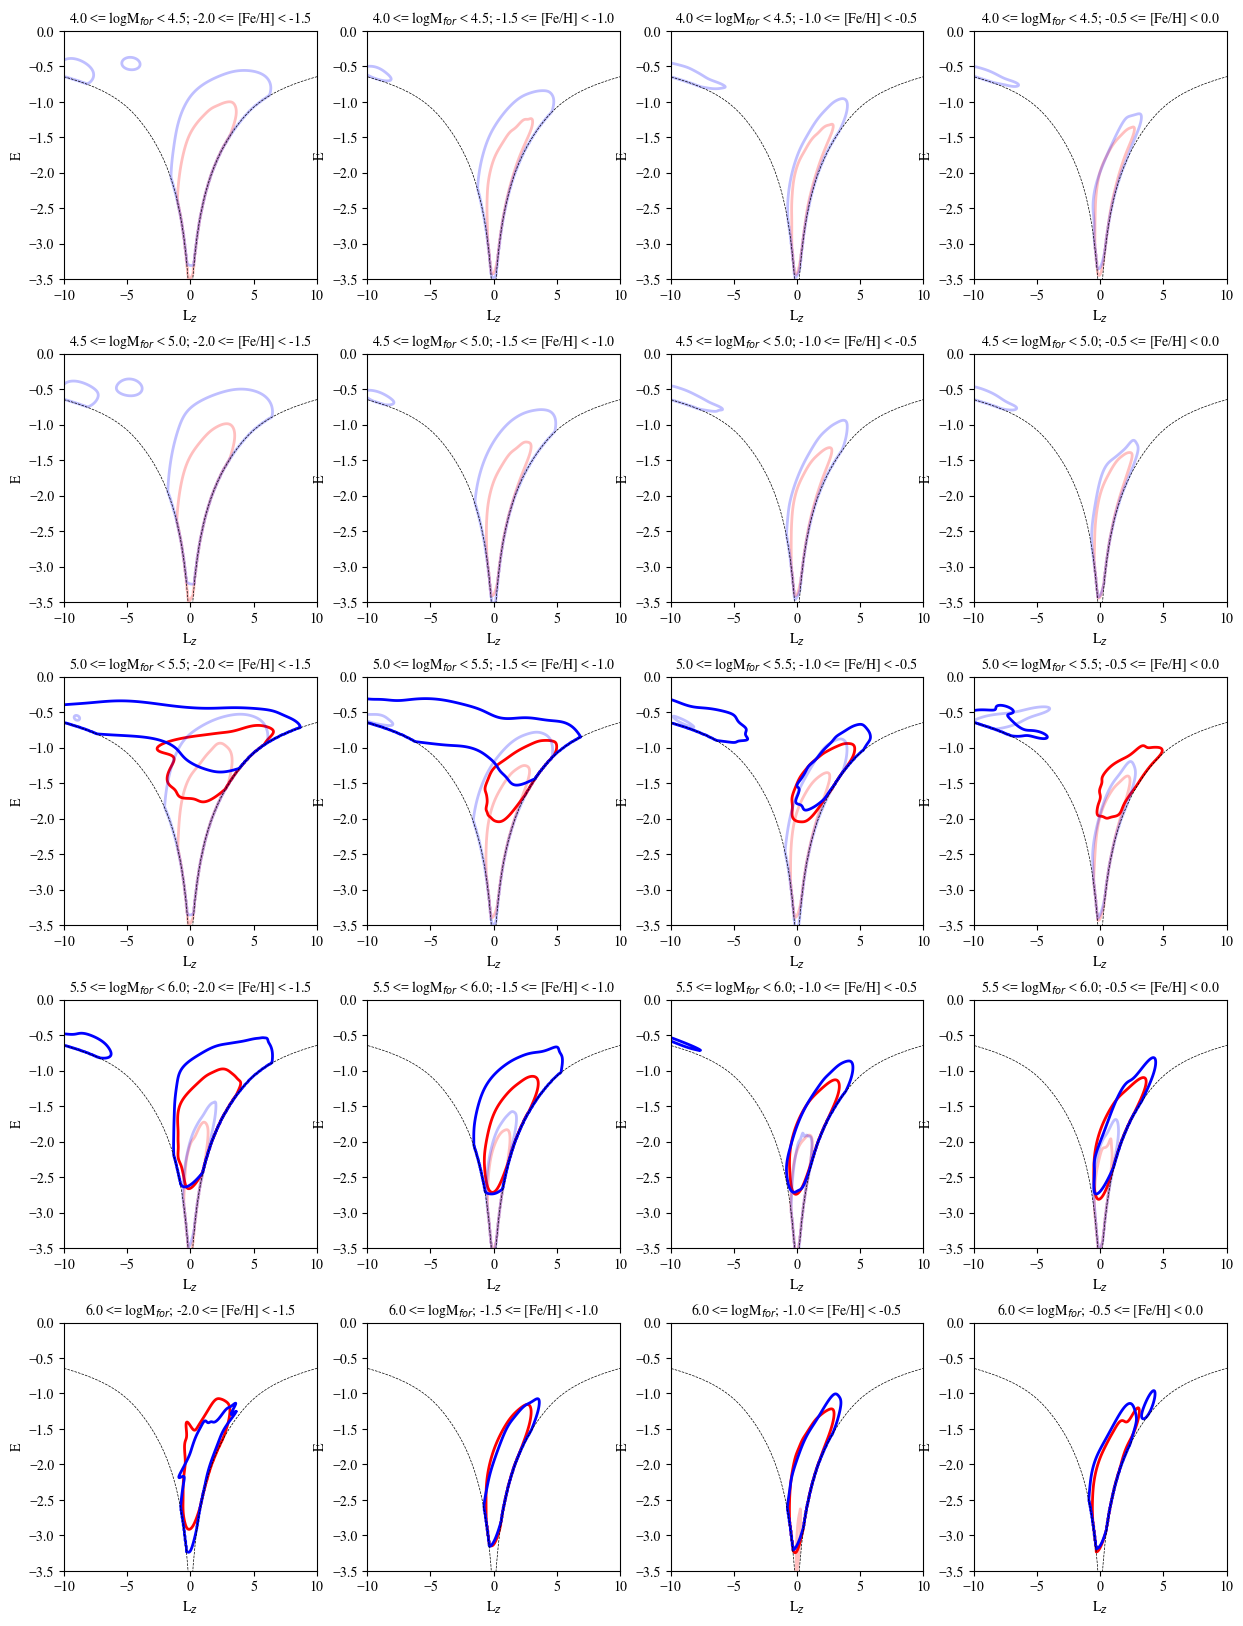

In [203]:
fig, axs = plt.subplots(nrows=5, ncols=4, figsize=(15, 20))
plt.subplots_adjust(hspace=0.3)

axs[0, 0].set_title(r"4.0 <= logM$_{for}$ < 4.5; -2.0 <= [Fe/H] < -1.5")
axs[1, 0].set_title(r"4.5 <= logM$_{for}$ < 5.0; -2.0 <= [Fe/H] < -1.5")
axs[2, 0].set_title(r"5.0 <= logM$_{for}$ < 5.5; -2.0 <= [Fe/H] < -1.5")
axs[3, 0].set_title(r"5.5 <= logM$_{for}$ < 6.0; -2.0 <= [Fe/H] < -1.5")
axs[4, 0].set_title(r"6.0 <= logM$_{for}$; -2.0 <= [Fe/H] < -1.5")

axs[0, 1].set_title(r"4.0 <= logM$_{for}$ < 4.5; -1.5 <= [Fe/H] < -1.0")
axs[1, 1].set_title(r"4.5 <= logM$_{for}$ < 5.0; -1.5 <= [Fe/H] < -1.0")
axs[2, 1].set_title(r"5.0 <= logM$_{for}$ < 5.5; -1.5 <= [Fe/H] < -1.0")
axs[3, 1].set_title(r"5.5 <= logM$_{for}$ < 6.0; -1.5 <= [Fe/H] < -1.0")
axs[4, 1].set_title(r"6.0 <= logM$_{for}$; -1.5 <= [Fe/H] < -1.0")

axs[0, 2].set_title(r"4.0 <= logM$_{for}$ < 4.5; -1.0 <= [Fe/H] < -0.5")
axs[1, 2].set_title(r"4.5 <= logM$_{for}$ < 5.0; -1.0 <= [Fe/H] < -0.5")
axs[2, 2].set_title(r"5.0 <= logM$_{for}$ < 5.5; -1.0 <= [Fe/H] < -0.5")
axs[3, 2].set_title(r"5.5 <= logM$_{for}$ < 6.0; -1.0 <= [Fe/H] < -0.5")
axs[4, 2].set_title(r"6.0 <= logM$_{for}$; -1.0 <= [Fe/H] < -0.5")

axs[0, 3].set_title(r"4.0 <= logM$_{for}$ < 4.5; -0.5 <= [Fe/H] < 0.0")
axs[1, 3].set_title(r"4.5 <= logM$_{for}$ < 5.0; -0.5 <= [Fe/H] < 0.0")
axs[2, 3].set_title(r"5.0 <= logM$_{for}$ < 5.5; -0.5 <= [Fe/H] < 0.0")
axs[3, 3].set_title(r"5.5 <= logM$_{for}$ < 6.0; -0.5 <= [Fe/H] < 0.0")
axs[4, 3].set_title(r"6.0 <= logM$_{for}$; -0.5 <= [Fe/H] < 0.0")

for i in range(5):
    for j in range(4):
        ax = axs[i, j]
        key = (i, j)

        if key in pdf_store["is"]:
            Z = pdf_store["is"][key]
            level = get_level(Z, cont_level)
            ax.contour(XX, YY, Z, levels=[level], colors="r", linewidths=2)

        if key in pdf_store["id"]:
            Z = pdf_store["id"][key]
            level = get_level(Z, cont_level)
            ax.contour(XX, YY, Z, levels=[level], colors="r", linewidths=2, alpha=0.25)

        if key in pdf_store["es"]:
            Z = pdf_store["es"][key]
            level = get_level(Z, cont_level)
            ax.contour(XX, YY, Z, levels=[level], colors="b", linewidths=2)

        if key in pdf_store["ed"]:
            Z = pdf_store["ed"][key]
            level = get_level(Z, cont_level)
            ax.contour(XX, YY, Z, levels=[level], colors="b", linewidths=2, alpha=0.25)

        ax.plot(lz_c * lz_scale, et_c * et_scale, "k--", lw=0.5)

        ax.set_xlim(-10, 10)
        ax.set_ylim(-3.5, 0)

        ax.set_xlabel(r"L$_z$")
        ax.set_ylabel(r"E")

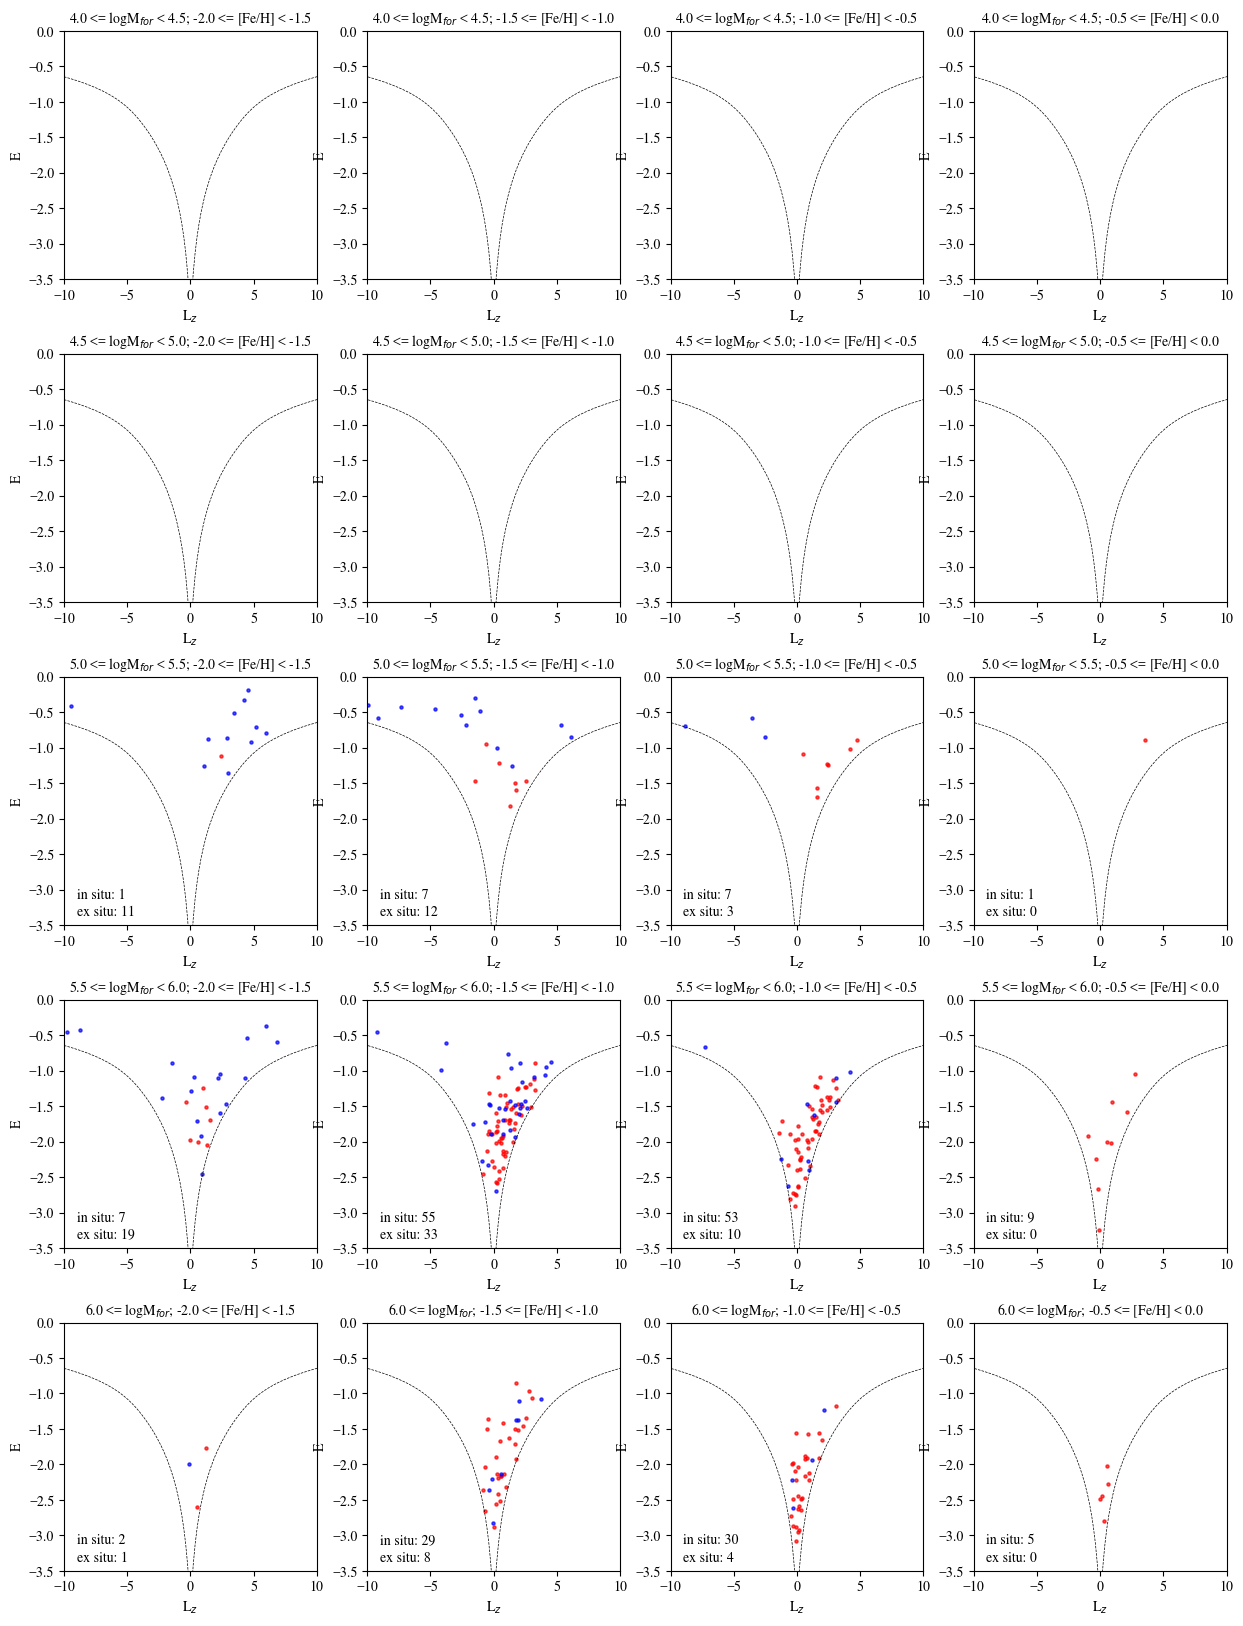

In [204]:
fig, axs = plt.subplots(nrows=5, ncols=4, figsize=(15, 20))
plt.subplots_adjust(hspace=0.3)

axs[0, 0].set_title(r"4.0 <= logM$_{for}$ < 4.5; -2.0 <= [Fe/H] < -1.5")
axs[1, 0].set_title(r"4.5 <= logM$_{for}$ < 5.0; -2.0 <= [Fe/H] < -1.5")
axs[2, 0].set_title(r"5.0 <= logM$_{for}$ < 5.5; -2.0 <= [Fe/H] < -1.5")
axs[3, 0].set_title(r"5.5 <= logM$_{for}$ < 6.0; -2.0 <= [Fe/H] < -1.5")
axs[4, 0].set_title(r"6.0 <= logM$_{for}$; -2.0 <= [Fe/H] < -1.5")

axs[0, 1].set_title(r"4.0 <= logM$_{for}$ < 4.5; -1.5 <= [Fe/H] < -1.0")
axs[1, 1].set_title(r"4.5 <= logM$_{for}$ < 5.0; -1.5 <= [Fe/H] < -1.0")
axs[2, 1].set_title(r"5.0 <= logM$_{for}$ < 5.5; -1.5 <= [Fe/H] < -1.0")
axs[3, 1].set_title(r"5.5 <= logM$_{for}$ < 6.0; -1.5 <= [Fe/H] < -1.0")
axs[4, 1].set_title(r"6.0 <= logM$_{for}$; -1.5 <= [Fe/H] < -1.0")

axs[0, 2].set_title(r"4.0 <= logM$_{for}$ < 4.5; -1.0 <= [Fe/H] < -0.5")
axs[1, 2].set_title(r"4.5 <= logM$_{for}$ < 5.0; -1.0 <= [Fe/H] < -0.5")
axs[2, 2].set_title(r"5.0 <= logM$_{for}$ < 5.5; -1.0 <= [Fe/H] < -0.5")
axs[3, 2].set_title(r"5.5 <= logM$_{for}$ < 6.0; -1.0 <= [Fe/H] < -0.5")
axs[4, 2].set_title(r"6.0 <= logM$_{for}$; -1.0 <= [Fe/H] < -0.5")

axs[0, 3].set_title(r"4.0 <= logM$_{for}$ < 4.5; -0.5 <= [Fe/H] < 0.0")
axs[1, 3].set_title(r"4.5 <= logM$_{for}$ < 5.0; -0.5 <= [Fe/H] < 0.0")
axs[2, 3].set_title(r"5.0 <= logM$_{for}$ < 5.5; -0.5 <= [Fe/H] < 0.0")
axs[3, 3].set_title(r"5.5 <= logM$_{for}$ < 6.0; -0.5 <= [Fe/H] < 0.0")
axs[4, 3].set_title(r"6.0 <= logM$_{for}$; -0.5 <= [Fe/H] < 0.0")

for i in range(5):
    for j in range(4):
        ax = axs[i, j]
        key = (i, j)

        if key in pdf_store["is"]:
            xs, ys = sample_from_pdf(pdf_store["is"][key], XX, YY, n_gc_store["is"][key])
            ax.scatter(xs, ys, s=5, c="r", alpha=0.7)

            test_is = "in situ: " + str(int(n_gc_store["is"][key]))
            ax.text(0.05, 0.15, test_is, transform=ax.transAxes, va="top", fontsize=10)

        # if key in pdf_store["id"]:
        #     xs, ys = sample_from_pdf(pdf_store["id"][key], XX, YY, n_gc_store["id"][key])
        #     ax.scatter(xs, ys, s=5, c="r", alpha=0.2)

        if key in pdf_store["es"]:
            xs, ys = sample_from_pdf(pdf_store["es"][key], XX, YY, n_gc_store["es"][key])
            ax.scatter(xs, ys, s=5, c="b", alpha=0.7)

            test_is = "ex situ: " + str(int(n_gc_store["es"][key]))
            ax.text(0.05, 0.08, test_is, transform=ax.transAxes, va="top", fontsize=10)

        # if key in pdf_store["ed"]:
        #     xs, ys = sample_from_pdf(pdf_store["ed"][key], XX, YY, n_gc_store["ed"][key])
        #     ax.scatter(xs, ys, s=5, c="b", alpha=0.2)

        ax.plot(lz_c * lz_scale, et_c * et_scale, "k--", lw=0.5)
        # ax.plot(lz_boundary, et_boundary, c="green", lw=1, zorder=0)

        ax.set_xlim(-10, 10)
        ax.set_ylim(-3.5, 0)

        ax.set_xlabel(r"L$_z$")
        ax.set_ylabel(r"E")

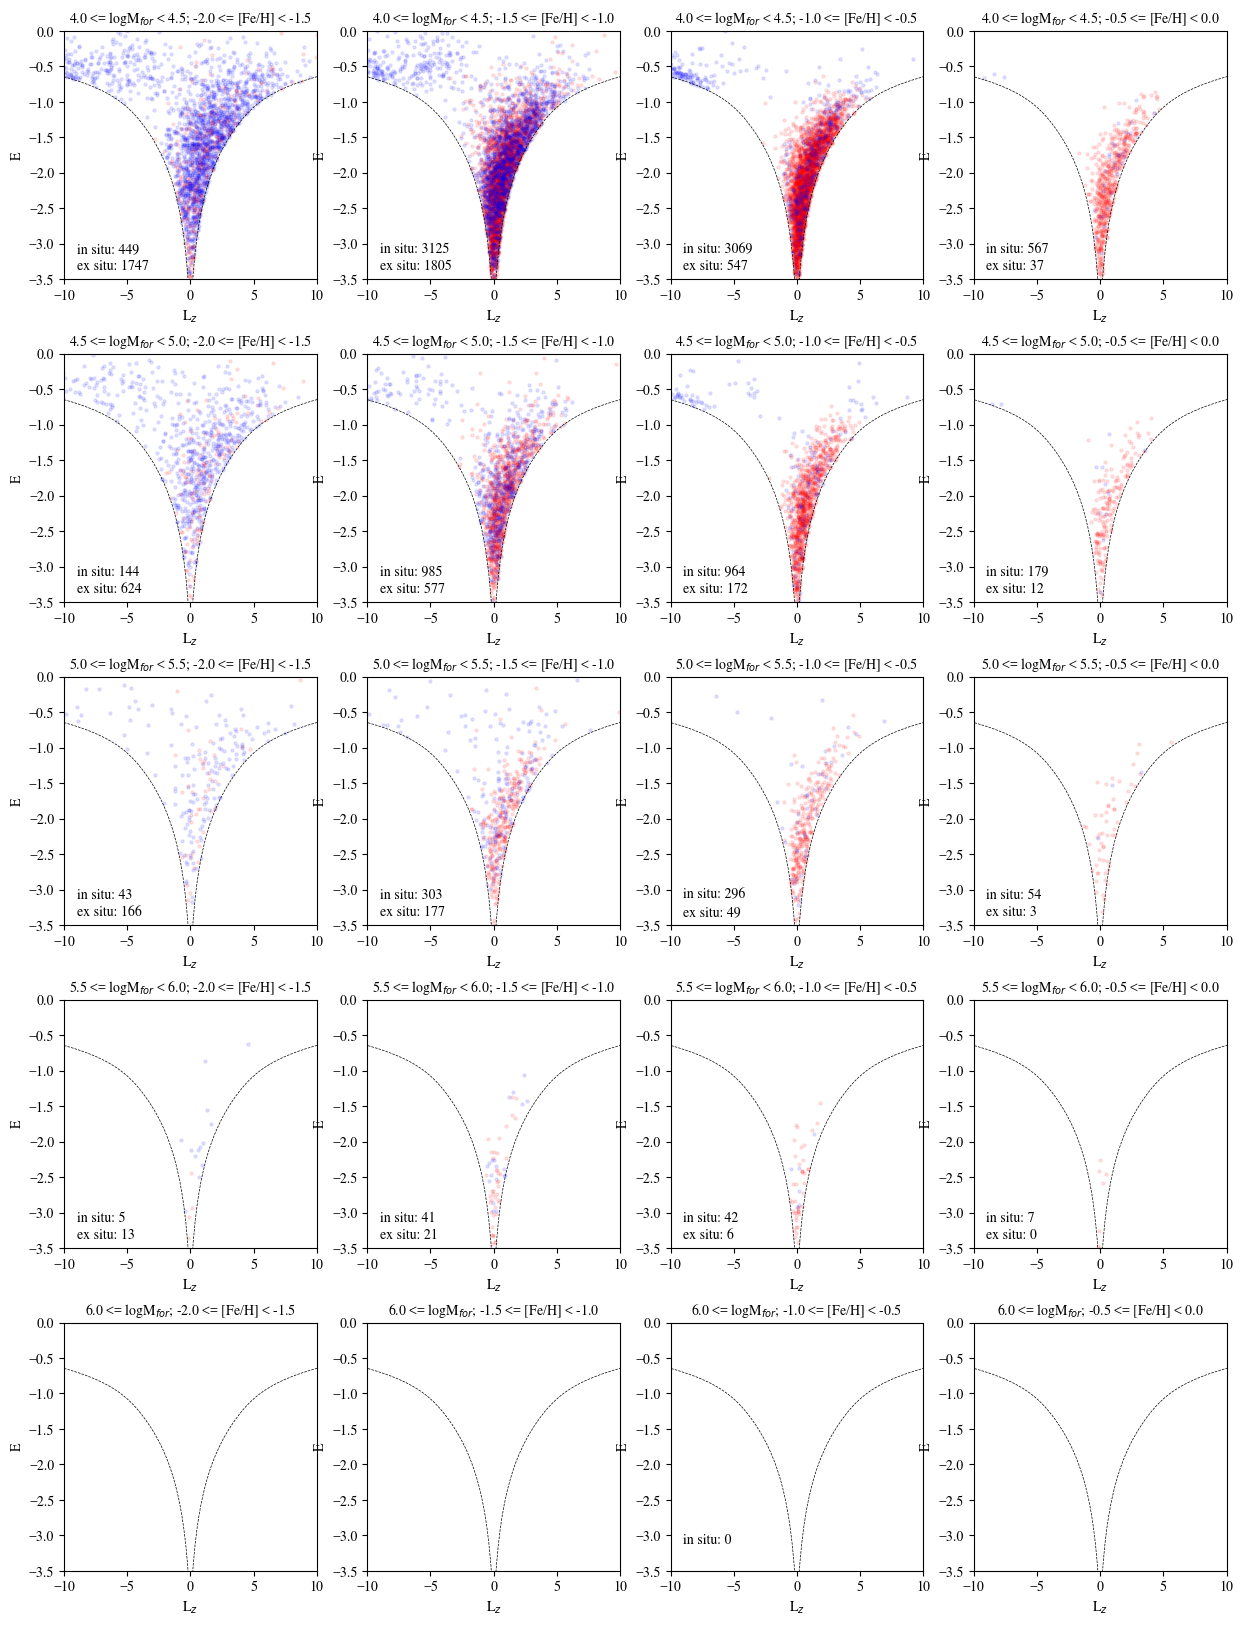

In [205]:
fig, axs = plt.subplots(nrows=5, ncols=4, figsize=(15, 20))
plt.subplots_adjust(hspace=0.3)

axs[0, 0].set_title(r"4.0 <= logM$_{for}$ < 4.5; -2.0 <= [Fe/H] < -1.5")
axs[1, 0].set_title(r"4.5 <= logM$_{for}$ < 5.0; -2.0 <= [Fe/H] < -1.5")
axs[2, 0].set_title(r"5.0 <= logM$_{for}$ < 5.5; -2.0 <= [Fe/H] < -1.5")
axs[3, 0].set_title(r"5.5 <= logM$_{for}$ < 6.0; -2.0 <= [Fe/H] < -1.5")
axs[4, 0].set_title(r"6.0 <= logM$_{for}$; -2.0 <= [Fe/H] < -1.5")

axs[0, 1].set_title(r"4.0 <= logM$_{for}$ < 4.5; -1.5 <= [Fe/H] < -1.0")
axs[1, 1].set_title(r"4.5 <= logM$_{for}$ < 5.0; -1.5 <= [Fe/H] < -1.0")
axs[2, 1].set_title(r"5.0 <= logM$_{for}$ < 5.5; -1.5 <= [Fe/H] < -1.0")
axs[3, 1].set_title(r"5.5 <= logM$_{for}$ < 6.0; -1.5 <= [Fe/H] < -1.0")
axs[4, 1].set_title(r"6.0 <= logM$_{for}$; -1.5 <= [Fe/H] < -1.0")

axs[0, 2].set_title(r"4.0 <= logM$_{for}$ < 4.5; -1.0 <= [Fe/H] < -0.5")
axs[1, 2].set_title(r"4.5 <= logM$_{for}$ < 5.0; -1.0 <= [Fe/H] < -0.5")
axs[2, 2].set_title(r"5.0 <= logM$_{for}$ < 5.5; -1.0 <= [Fe/H] < -0.5")
axs[3, 2].set_title(r"5.5 <= logM$_{for}$ < 6.0; -1.0 <= [Fe/H] < -0.5")
axs[4, 2].set_title(r"6.0 <= logM$_{for}$; -1.0 <= [Fe/H] < -0.5")

axs[0, 3].set_title(r"4.0 <= logM$_{for}$ < 4.5; -0.5 <= [Fe/H] < 0.0")
axs[1, 3].set_title(r"4.5 <= logM$_{for}$ < 5.0; -0.5 <= [Fe/H] < 0.0")
axs[2, 3].set_title(r"5.0 <= logM$_{for}$ < 5.5; -0.5 <= [Fe/H] < 0.0")
axs[3, 3].set_title(r"5.5 <= logM$_{for}$ < 6.0; -0.5 <= [Fe/H] < 0.0")
axs[4, 3].set_title(r"6.0 <= logM$_{for}$; -0.5 <= [Fe/H] < 0.0")

for i in range(5):
    for j in range(4):
        ax = axs[i, j]
        key = (i, j)

        if key in pdf_store["id"]:
            xs, ys = sample_from_pdf(pdf_store["id"][key], XX, YY, n_gc_store["id"][key])
            ax.scatter(xs, ys, s=5, c="r", alpha=0.10)

            test_is = "in situ: " + str(int(n_gc_store["id"][key]))
            ax.text(0.05, 0.15, test_is, transform=ax.transAxes, va="top", fontsize=10)

        # if key in pdf_store["id"]:
        #     xs, ys = sample_from_pdf(pdf_store["id"][key], XX, YY, n_gc_store["id"][key])
        #     ax.scatter(xs, ys, s=5, c="r", alpha=0.2)

        if key in pdf_store["ed"]:
            xs, ys = sample_from_pdf(pdf_store["ed"][key], XX, YY, n_gc_store["ed"][key])
            ax.scatter(xs, ys, s=5, c="b", alpha=0.10)

            test_is = "ex situ: " + str(int(n_gc_store["ed"][key]))
            ax.text(0.05, 0.08, test_is, transform=ax.transAxes, va="top", fontsize=10)

        # if key in pdf_store["ed"]:
        #     xs, ys = sample_from_pdf(pdf_store["ed"][key], XX, YY, n_gc_store["ed"][key])
        #     ax.scatter(xs, ys, s=5, c="b", alpha=0.2)

        ax.plot(lz_c * lz_scale, et_c * et_scale, "k--", lw=0.5)
        # ax.plot(lz_boundary, et_boundary, c="green", lw=1, zorder=0)

        ax.set_xlim(-10, 10)
        ax.set_ylim(-3.5, 0)

        ax.set_xlabel(r"L$_z$")
        ax.set_ylabel(r"E")